# EOS database demo: testing after several pull requests

Testing the database after 4 pull requests from 4 different contributors.

## 1. Loading the database

Start by importing the database class. All code lives under `./modules`.

In [1]:
from modules.eosdatabase import EOSDatabase
from modules.functions import *

Provide the folder containing all the data to load, here `"./data"`.<br>

The tool parses automatically thermodynamic data files `*_thermo.dat`, equation of state files `*_eos.dat`, and information on source files `*_source.dat`.<br>

Use `verbose=0`for minimal output, or `verbose=1` to get a message for every file loaded.

In [2]:
database = EOSDatabase("./data",verbose=1)

Loaded thermo-data file: data/solomatovacaracas2021/solomatovacaracas2021_pyrolite_thermo.dat
Loaded thermo-data file: data/fischer2011/fischer2011_b8feo_thermo.dat
Loaded thermo-data file: data/fischer2011/fischer2011_b1feo_thermo.dat
Loaded thermo-data file: data/miozzi2020/miozzi2020_hcpfe-lowP_thermo.dat
Loaded thermo-data file: data/miozzi2020/miozzi2020_hcpfe-highP_thermo.dat
Loaded thermo-data file: data/caracas2024/caracas2024_pyrolite_thermo.dat
Loaded thermo-data file: data/hakim2018/hakim2018_hcpfe_thermo.dat
Loaded source file: data/solomatovacaracas2021/solomatovacaracas2021_source.toml
Loaded source file: data/fischer2011/fischer2011_source.toml
Loaded source file: data/canoamoros2026/canoamoros2026_H2O_source.toml
Loaded source file: data/miozzi2020/miozzi2020_source.toml
Loaded source file: data/caracas2024/caracas2024_source.toml
Loaded source file: data/hollandpowell2011/hollandpowell2011_source.toml
Loaded source file: data/dorogokupets2017/dorogokupets2017_source.to

At this point, you can verify that all data was loaded successfully. It does not guarantee that everything is in the right format, but it at least guarantees that all files have been found and loaded. Please make sure that at least this step works before making adding new entries to the catalog.

## 2. Printing stuff

There are several built-in tools to quickly and efficiently see various data sets that were loaded.

For example, you can **print a summary of all thermodynamic data**.

In [3]:
database.summary_thermo()

EOSDatabase summary thermo
--------------------------
Rows   : 564
Columns: 28
--------------------------
caracas2024 (NaCa2Al3Fe4Mg30Si24O65)
fischer2011 (FeO)
hakim2018 (Fe)
miozzi2020 (Fe)
solomatovacaracas2021 (NaCa2Al3Fe4Mg30Si24O65)


Another example is you can print just the available species.

In [4]:
database.print_species_thermo()

Species in thermo database
--------------------------

iron
  - Fe : hakim2018
  - Fe : miozzi2020

pyrolite
  - NaCa2Al3Fe4Mg30Si24O65 : caracas2024
  - NaCa2Al3Fe4Mg30Si24O65 : solomatovacaracas2021

wustite
  - FeO : fischer2011


*For developpers*: all the data is just a giant pandas dataframe. If you are more familiar with pandas dataframes, you can just use them instead.

In [5]:
import pandas as pd
dataframe_thermo = database.df_thermo
# print the available keys of the dataframe
print(dataframe_thermo.keys())
# print just the P-rho-T-citation info
print(dataframe_thermo[["P[GPa]","rho[g/cm^3]","T[K]","entry"]])

Index(['V[Angstroms^3]', 'rho[g/cm^3]', 'P[GPa]', 'Pst.dev.[GPa]', 'T[K]',
       'Tst.dev.[K]', 'unique_id', 'science_material', 'science_formula',
       'science_phase', 'science_method', 'data_delimiter', 'label', 'entry',
       'rho[kg/m^3]', 'drho[kg/m^3]', 'V[m^3/mol]', 'dV[m^3/mol]', 'P[Pa]',
       'dP[Pa]', 'dT[K]', 'c/a', 'dc/a', 'science_cristal', 'other_notes',
       'MDsteps', 'dP[GPa]', 'U[kJ/kg]'],
      dtype='object')
            P[GPa]  rho[g/cm^3]     T[K]                           entry
0        36.200000     4.040000  1994.22  solomatovacaracas2021_pyrolite
1        19.420000     3.530000  1995.31  solomatovacaracas2021_pyrolite
2         8.720000     3.110000  1994.66  solomatovacaracas2021_pyrolite
3         3.110000     2.750000  1995.34  solomatovacaracas2021_pyrolite
4        -0.420000     2.440000  1999.77  solomatovacaracas2021_pyrolite
..             ...          ...      ...                             ...
559  121630.849640   105.886608   300.00       

## 3. Manipulating the database

It is particularly useful to be able to manipulate the database.<br>

One possibility is to filter out specific properties. Specify which property (column) you are filtering for, and specify which values to keep.<br>

First, list all the fields we can use our filters on.

In [6]:
print("Columns of bibliography (source): ")
print(database.columns_source())
print()

print("Columns of thermo data: ")
print(database.columns_thermo())
print()

print("Columns of EOS: ")
print(database.columns_eos())
print()



Columns of bibliography (source): 
['unique_id', 'citation', 'year', 'doi', 'source_file', 'title', 'journal']

Columns of thermo data: 
['V[Angstroms^3]', 'rho[g/cm^3]', 'P[GPa]', 'Pst.dev.[GPa]', 'T[K]', 'Tst.dev.[K]', 'unique_id', 'science_material', 'science_formula', 'science_phase', 'science_method', 'data_delimiter', 'label', 'entry', 'rho[kg/m^3]', 'drho[kg/m^3]', 'V[m^3/mol]', 'dV[m^3/mol]', 'P[Pa]', 'dP[Pa]', 'dT[K]', 'c/a', 'dc/a', 'science_cristal', 'other_notes', 'MDsteps', 'dP[GPa]', 'U[kJ/kg]']

Columns of EOS: 
['unique_id', 'science_material', 'science_formula', 'science_phase', 'science_cristal', 'science_method', 'description_type', 'description_cold_type', 'description_thermal_exist', 'description_thermal_type', 'description_reference_temperature', 'validity_min_p', 'validity_max_p', 'validity_min_t', 'validity_max_t', 'validity_min_rho', 'validity_max_rho', 'parameters_V_0', 'parameters_rho_0', 'parameters_K_0', 'parameters_dK_0', 'parameters_K_0_prime', 'parameter

Let's say we want a sub-database containing only information about wustite:

In [7]:
db_wustite = database.filter_out(
    field="science_material",
    contains="wustite",
)

db_wustite.print_species_thermo()

Species in thermo database
--------------------------

wustite
  - FeO : fischer2011


## 4. Outputs: plots and writing to file

Write current database to a file (messy, work in progress).<br>
Automatically adds the date when the table was exported.

In [8]:
db_wustite.export_tsv(filename="thermo_wustite")


Export complete
File: output/thermo_wustite_20260701.tsv
Rows exported: 63


Plotting the filtered database: $P(\rho)$ with the colorbar being $T$.

Found 2 entries


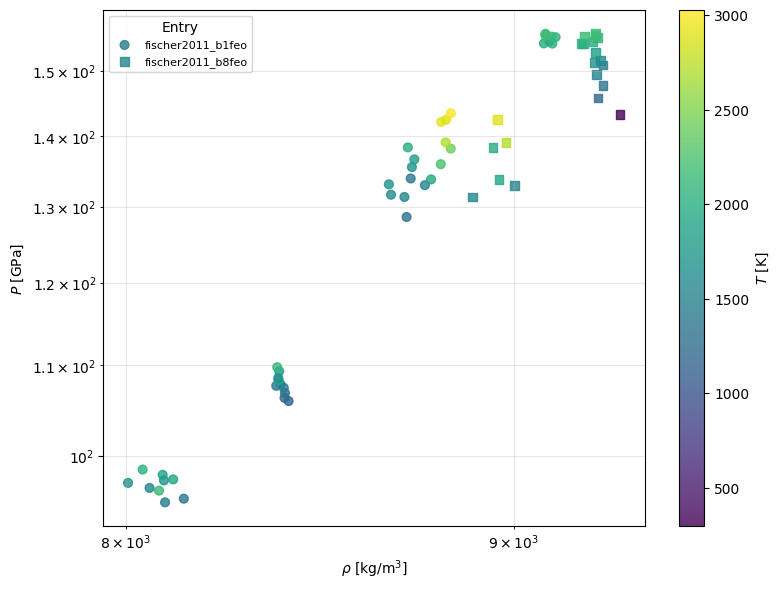

In [9]:
db_wustite.plot_rhopt()

Use `plt_show=False` so that the plot is loaded into memory, and you can customize it before displaying (or saving it).

Found 2 entries


(120.0, 160.0)

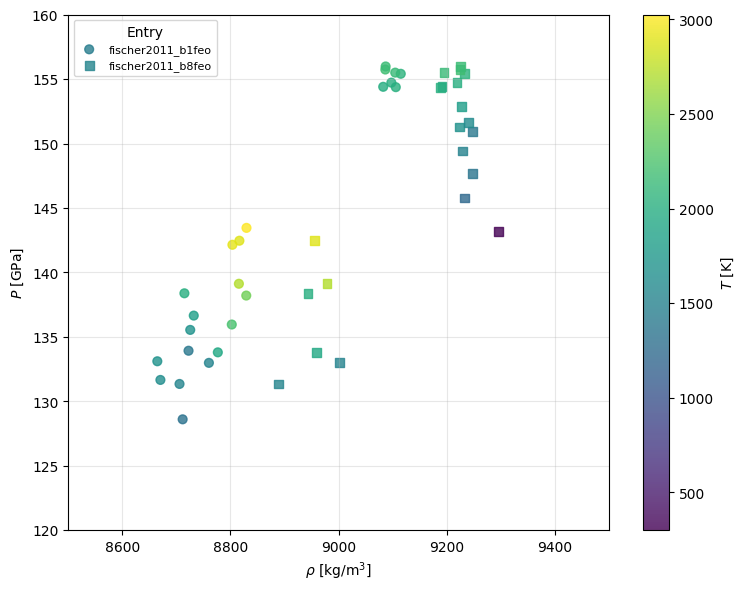

In [10]:
import matplotlib.pyplot as plt
db_wustite.plot_rhopt(plt_show=False)
plt.xscale('linear')
plt.yscale('linear')
plt.xlim(8500,9500) #x-axis in kg/m^3
plt.ylim(120,160) #y-axis in GPa

# 5. EOS <a id='section_eos'></a>

The same python object contains sources, thermo data, and EOSs.<br>

To work with EOS, the functionality is basically the same.<br>
Note: results displayed are grouped by source+formula to save a little bit of space.

In [11]:
database.summary_eos()

EOSDatabase summary eos
-----------------------
Rows   : 14
Columns: 44
-----------------------
canoamoros2026 (H2O)
dorogokupets2017 (Fe)
fischer2011 (FeO)
hollandpowell2011 (Fe2Si2O6)
hollandpowell2011 (Fe2SiO4)
hollandpowell2011 (Mg2Si2O6)
hollandpowell2011 (Mg2SiO4)
miozzi2020 (Fe)


Sorting by species instead:

In [12]:
database.print_species_eos()

Species in eos database
-----------------------

enstatite
  - Mg2Si2O6 : hollandpowell2011

fayalite
  - Fe2SiO4 : hollandpowell2011

ferrosilite
  - Fe2Si2O6 : hollandpowell2011

forsterite
  - Mg2SiO4 : hollandpowell2011

iron
  - Fe : dorogokupets2017
  - Fe : miozzi2020

water
  - H2O : canoamoros2026

wustite
  - FeO : fischer2011


If we want to work with just one EOS of interest, it's a good idea to extract it from the full catalog. <br>
First, search for available entries, then get that entry.

In [13]:
database.show_unique_eos()

  index  entry
      0  fischer2011_b1feo
      1  fischer2011_b8feo
      2  canoamoros2026_H2O
      3  miozzi2020_hcpfe
      4  hollandpowell2011_forsterite
      5  hollandpowell2011_ferrosilite
      6  hollandpowell2011_fayalite
      7  hollandpowell2011_fayalite-liq
      8  hollandpowell2011_enstatite
      9  hollandpowell2011_forsterite-liq
     10  dorogokupets2017_bccfe
     11  dorogokupets2017_hcpfe
     12  dorogokupets2017_liquidfe
     13  dorogokupets2017_fccfe


In [14]:
fischer_B1FeO_eos = database.get_eos(entry="fischer2011_b1feo")

And then use the existing functions to get information from that EOS.

In [15]:
print_eos(fischer_B1FeO_eos)

Science of entry:  fischer2011_b1feo
-------
material: wustite
formula: FeO
phase: solid
cristal: B1
method: LH-DAC XRD

Description of entry:  fischer2011_b1feo
-----------
type: fit
cold_type: bm3
thermal_exist: True
thermal_type: debye
reference_temperature: 300.0

Validity of entry:  fischer2011_b1feo
--------
min_p: 95215331893.3
max_p: 155982534269.0
min_t: 1143.9
max_t: 3024.73
min_rho: 8005.61090858
max_rho: 9114.71886257

Parameters of entry:  fischer2011_b1feo
----------
V_0: 12.256
rho_0: 5.86194516971
K_0: 149.4
dK_0: 1.0
K_0_prime: 3.6
dK_0_prime: 0.04
T_0: 300.0
theta_0: 417.0
gamma_0: 1.41
dgamma_0: 0.05
q_debye: 0.5



Or you can print individual sections...

In [16]:
# print_science(fischer_B1FeO_eos)
print_description(fischer_B1FeO_eos);print()
# print_validity(fischer_B1FeO_eos)
print_parameters(fischer_B1FeO_eos)

Description of entry:  fischer2011_b1feo
-----------
type: fit
cold_type: bm3
thermal_exist: True
thermal_type: debye
reference_temperature: 300.0

Parameters of entry:  fischer2011_b1feo
----------
V_0: 12.256
rho_0: 5.86194516971
K_0: 149.4
dK_0: 1.0
K_0_prime: 3.6
dK_0_prime: 0.04
T_0: 300.0
theta_0: 417.0
gamma_0: 1.41
dgamma_0: 0.05
q_debye: 0.5
